In [6]:
import pandas as pd

# ================= 1. 读取数据 =================
ch0 = pd.read_csv("/data/data/jiancheng/SourceRecon_data/compton_work_0513/compton_work_100_100_100_40pt_28.5V_4hours_0513_rd_ch0.txt",sep="\t")
ch1 = pd.read_csv("/data/data/jiancheng/SourceRecon_data/compton_work_0513/compton_work_100_100_100_40pt_28.5V_4hours_0513_rd_ch1.txt",sep="\t")
ch2 = pd.read_csv("/data/data/jiancheng/SourceRecon_data/compton_work_0513/compton_work_100_100_100_40pt_28.5V_4hours_0513_rd_ch2.txt",sep="\t")

# # print(ch0)
# for ch in [ch0, ch1, ch2]:
# ch2["z"] = -61.5

energy_response_ch0 = pd.read_csv("/data/data/compton_camera/calib_result/Calib_28.5V_new_firmware_40pt/calibration_results_fixed_ch0/calibration_results.txt",sep="\t")
energy_response_ch1 = pd.read_csv("/data/data/compton_camera/calib_result/Calib_28.5V_new_firmware_40pt/calibration_results_fixed_ch1/calibration_results.txt",sep="\t")
energy_response_ch2 = pd.read_csv("/data/data/compton_camera/calib_result/Calib_28.5V_new_firmware_40pt/calibration_results_fixed_ch2/calibration_results.txt",sep="\t")

# ================= 2. 定义处理单通道数据的函数 =================
def process_channel(df_raw, df_calib, prefix):
    # 利用 PixelID 将原始数据与刻度参数 (a 和 b) 匹配合并
    # 使用 left join 保证不丢失原始 event
    merged = pd.merge(df_raw, df_calib[['PixelID', 'a(keV/ADC)', 'b(keV)']], 
                      on='PixelID', how='left')
    
    # 计算能量: Energy(keV) = ADC * a + b
    # 注意: 如果你的 TotalEnergy 为 0 代表未击中，可能需要将计算后的能量强制设为 0 或者 NaN
    merged['energy_keV'] = merged['TotalEnergy'] * merged['a(keV/ADC)'] + merged['b(keV)']
    
    # 转换为 MeV: Energy(MeV) = Energy(keV) / 1000
    merged['energy_MeV'] = merged['energy_keV'] / 1000.0
    
    # 针对 0 能量事件过滤（可选）：如果 ADC 是 0，算出来会有个 b(keV) 的截距本底。
    # 如果你要把未触发的像素能量强制设为 0，可以取消下面这行的注释：
    # merged.loc[merged['TotalEnergy'] == 0, 'energy_MeV'] = 0.0

    # 重命名列以区分不同通道，比如 pos_x_mm -> ch0_x
    merged = merged.rename(columns={
        'PixelID': f'{prefix}_pixelid',
        'pos_x_mm': f'{prefix}_x',
        'pos_y_mm': f'{prefix}_y',
        'z': f'{prefix}_z',
        'energy_MeV': f'{prefix}_energy'
    })
    
    # 只保留合并需要的列
    cols_to_keep = ['EventID', f'{prefix}_pixelid', f'{prefix}_x', f'{prefix}_y', f'{prefix}_z', f'{prefix}_energy']
    return merged[cols_to_keep]

# ================= 3. 对每个通道进行刻度转换 =================
df0_processed = process_channel(ch0, energy_response_ch0, 'ch0')
df1_processed = process_channel(ch1, energy_response_ch1, 'ch1')
df2_processed = process_channel(ch2, energy_response_ch2, 'ch2')

# ================= 4. 按 EventID 合并所有通道 =================
# 使用 outer join (外连接) 确保任何在一个通道出现过的 EventID 都会被保留
# 如果某个 event 在 ch1 没有信号，那对应的 ch1_x 等值将会是 NaN
final_df = pd.merge(df0_processed, df1_processed, on='EventID', how='outer')
final_df = pd.merge(final_df, df2_processed, on='EventID', how='outer')

# 按照 EventID 排序并重置索引，看起来更整洁
final_df = final_df.sort_values(by='EventID').reset_index(drop=True)

# 打印查看最终结果
print(final_df.head(10))

     EventID  ch0_pixelid  ch0_x  ch0_y  ch0_z  ch0_energy  ch1_pixelid  \
0   12147770            0   0.00   0.00  -61.5         NaN          123   
1   40771193            0   0.00   0.00  -61.5         NaN           54   
2   57713911            0   0.00   0.00  -61.5         NaN           48   
3   71057980            0   0.00   0.00  -61.5         NaN          191   
4   81850693            0   0.00   0.00  -61.5         NaN          117   
5  109996941            0   0.00   0.00  -61.5         NaN           95   
6  144497350           11   0.00 -13.44  -61.5    0.103025           81   
7  156049313            0   0.00   0.00  -61.5         NaN          178   
8  197550213           31  -6.72   6.72  -61.5    0.475510          174   
9  201746901            0   0.00   0.00  -61.5         NaN           11   

   ch1_x  ch1_y  ch1_z  ch1_energy  ch2_pixelid  ch2_x  ch2_y  ch2_z  \
0  11.76   5.04    -25    0.073149          135   5.04   8.40      0   
1  15.12 -11.76    -25    0.23

In [7]:
##因为ch1和ch2 的adc有负数的
print(final_df[final_df['ch1_energy'].isnull()][['EventID', 'ch1_energy']])

             EventID  ch1_energy
6153    124652745581         NaN
9065    183957686206         NaN
15611   318135244163         NaN
21047   429369834047         NaN
22908   468109236601         NaN
23301   475672952260         NaN
23431   478729222268         NaN
23433   478779007159         NaN
24992   512035333941         NaN
31871   653377583046         NaN
39422   809680359377         NaN
40978   841860263487         NaN
42942   882593006959         NaN
43786   900697291984         NaN
47957   987990621712         NaN
56274  1159080025014         NaN
76327  1570755904642         NaN
82747  1701658876436         NaN
86508  1778095147723         NaN
90917  1869746870155         NaN


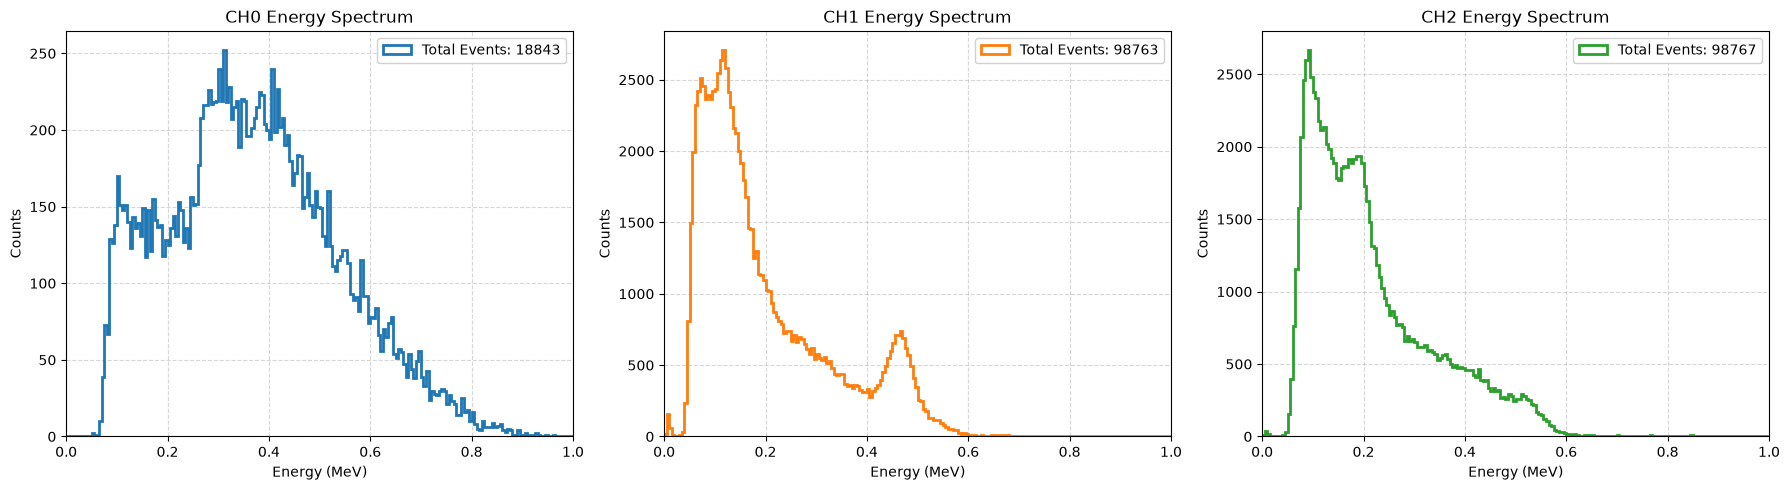

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. 定义高斯函数 (用于 0.662 MeV 峰拟合)
def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 设置画布布局 (1行3列)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
channels = ['ch0', 'ch1', 'ch2']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 定义拟合区间 (围绕 Cs-137 的 0.662 MeV 峰)
fit_min = 0.60
fit_max = 0.72

# 绘制能谱的范围和 bin 数量
plot_min = 0
plot_max = 1
n_bins = 200

for i, ch in enumerate(channels):
    ax = axes[i]
    
    # 提取当前通道能量数据，去除 NaN 以及 0 能量事件
    energy_data = final_df[f'{ch}_energy'].dropna()
    energy_data = energy_data[energy_data > 0]
    total_events = len(energy_data)
    
    # 绘制原始直方图，获取 counts 和 bin_edges 用于拟合
    counts, bin_edges, _ = ax.hist(energy_data, bins=n_bins, range=(plot_min, plot_max), 
                                   color=colors[i], alpha=1,linewidth=2, histtype="step",label=f'Total Events: {total_events}')
    
    # 计算 bin 中心点
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 筛选出位于拟合区间内的数据
    mask = (bin_centers >= fit_min) & (bin_centers <= fit_max)
    x_fit = bin_centers[mask]
    y_fit = counts[mask]
    
    # if len(x_fit) > 0 and max(y_fit) > 0:
    #     # 设置拟合初始参数 p0 = [振幅, 均值, 标准差]
    #     p0 = [max(y_fit), 0.662, 0.02]
        
    #     try:
            
    #         # 执行高斯拟合
    #         popt, pcov = curve_fit(gauss, x_fit, y_fit, p0=p0)
    #         a_opt, mu_opt, sigma_opt = popt
    #         sigma_opt = abs(sigma_opt)  # 确保 sigma 为正值
            
    #         # 计算能量分辨率: R = FWHM / mu = (2.355 * sigma) / mu
    #         fwhm = 2.355 * sigma_opt
    #         resolution = (fwhm / mu_opt) * 100
            
    #         # 生成拟合曲线的 x 和 y 点
    #         x_plot = np.linspace(fit_min, fit_max, 100)
    #         y_plot = gauss(x_plot, *popt)
            
    #         # 将拟合结果写入 Legend
    #         fit_label = (f'Fit (0.662 MeV):\n'
    #                      f'$\\mu$ = {mu_opt:.4f} MeV\n'
    #                      f'$\\sigma$ = {sigma_opt:.4f} MeV\n'
    #                      f'Res = {resolution:.2f}%')
            
    #         ax.plot(x_plot, y_plot, 'k--', linewidth=2, label=fit_label)
            
    #     except Exception as e:
    #         print(f"Channel {ch} 高斯拟合失败: {e}")
            
    # 图表细节美化
    ax.set_title(f'{ch.upper()} Energy Spectrum')
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Counts')
    # 将 y 轴刻度限制在合理范围，或者使用对数坐标 ax.set_yscale('log') 如果低能本底太高
    ax.set_xlim(plot_min, plot_max)
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


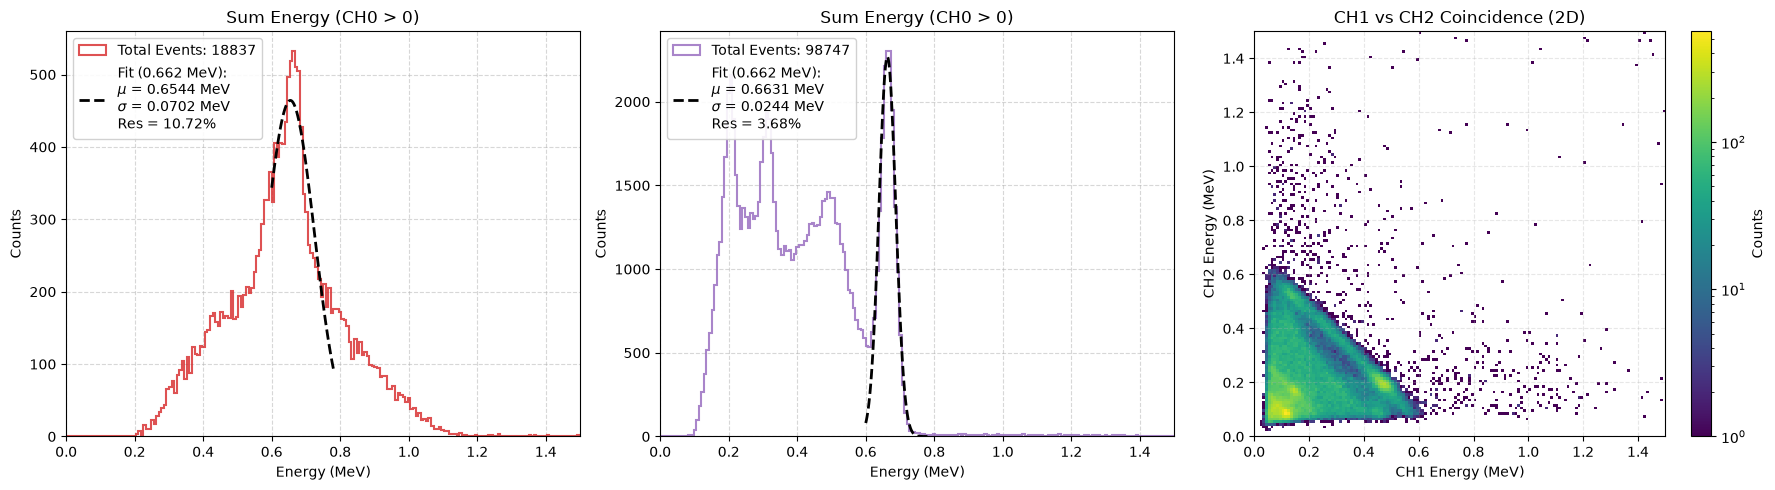

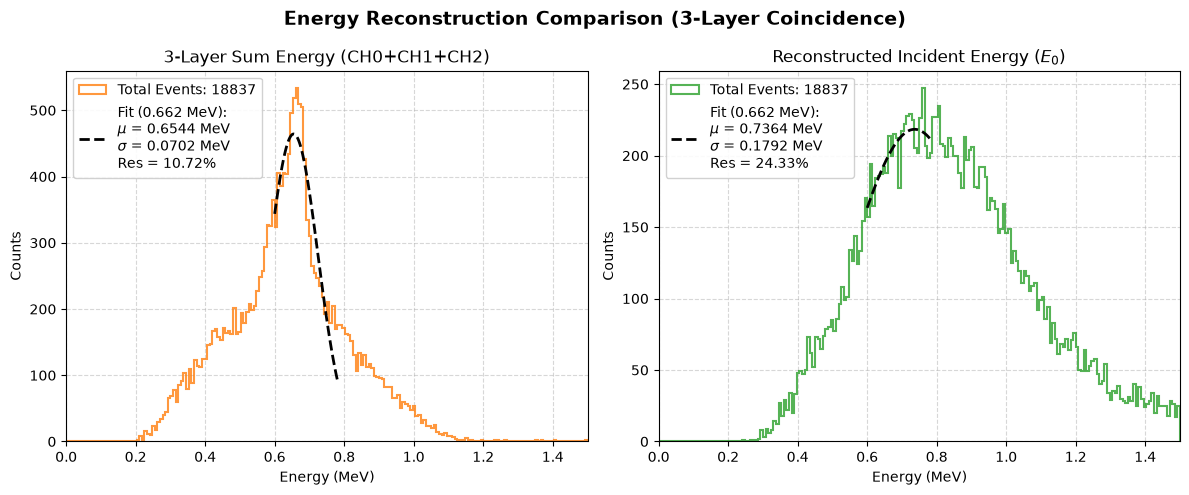

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

# 1. 定义高斯函数 (用于 0.662 MeV 峰拟合)
def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

# 2. 准备数据：处理 NaN 值
e_ch0 = final_df['ch0_energy'].fillna(0)
e_ch1 = final_df['ch1_energy'].fillna(0)
e_ch2 = final_df['ch2_energy'].fillna(0)

# ================= 核心修改区：严格符合筛选 =================
# 定义掩码：三个通道都必须大于 0
mask_all3 = (e_ch0 > 0) & (e_ch1 > 0) & (e_ch2 > 0)
# 应用掩码并计算总能量
e_sum_all = (e_ch0 + e_ch1 + e_ch2)[mask_all3]

# 定义掩码：CH1 和 CH2 都必须大于 0
mask_12 = (e_ch1 > 0) & (e_ch2 > 0)
# 应用掩码并计算 CH1+CH2 能量
e_sum_12 = (e_ch1 + e_ch2)[mask_12]

# 为 2D 亮度图准备数据：直接复用 mask_12
e_ch1_2d = e_ch1[mask_12]
e_ch2_2d = e_ch2[mask_12]
# =========================================================

# 3. 设置画布布局 (1行3列)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 定义拟合和绘图的全局参数
plot_min = 0.0
plot_max = 1.5
n_bins = 200
fit_min = 0.60
fit_max = 0.78

# 定义绘图与拟合复用函数
def plot_and_fit(ax, data, title, color):
    total_events = len(data)
    
    # 绘制直方图
    counts, bin_edges, _ = ax.hist(data, bins=n_bins, range=(plot_min, plot_max), 
                                   color=color, alpha=0.8, histtype="step", linewidth=1.5,
                                   label=f'Total Events: {total_events}')
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    mask = (bin_centers >= fit_min) & (bin_centers <= fit_max)
    x_fit = bin_centers[mask]
    y_fit = counts[mask]
    
    if len(x_fit) > 0 and max(y_fit) > 0:
        p0 = [max(y_fit), 0.662, 0.02]
        try:
            popt, pcov = curve_fit(gauss, x_fit, y_fit, p0=p0)
            a_opt, mu_opt, sigma_opt = popt
            sigma_opt = abs(sigma_opt)
            
            # 分辨率计算
            resolution = (sigma_opt / mu_opt) * 100
            
            x_plot = np.linspace(fit_min, fit_max, 100)
            y_plot = gauss(x_plot, *popt)
            
            fit_label = (f'Fit (0.662 MeV):\n'
                         f'$\\mu$ = {mu_opt:.4f} MeV\n'
                         f'$\\sigma$ = {sigma_opt:.4f} MeV\n'
                         f'Res = {resolution:.2f}%')
            
            ax.plot(x_plot, y_plot, 'k--', linewidth=2, label=fit_label)
        except Exception as e:
            print(f"{title} 高斯拟合失败: {e}")
            
    ax.set_title(title)
    ax.set_xlabel('Energy (MeV)')
    ax.set_ylabel('Counts')
    ax.set_xlim(plot_min, plot_max)
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.5)

# ================= 4. 开始绘图 =================

# 图 1: CH0 + CH1 + CH2 能量之和及拟合 (仅限三通道符合事件)
plot_and_fit(axes[0], e_sum_all, 'Sum Energy (CH0 > 0)', '#d62728')

# 图 2: CH1 + CH2 能量之和及拟合 (仅限双通道符合事件)
plot_and_fit(axes[1], e_sum_12, 'Sum Energy (CH0 > 0)', '#9467bd')

# 图 3: CH1 vs CH2 的二维亮度图 (2D Histogram)
h, xedges, yedges, image = axes[2].hist2d(e_ch1_2d, e_ch2_2d, bins=150, 
                                          range=[[plot_min, plot_max], [plot_min, plot_max]], 
                                          cmap='viridis', cmin=1,norm=LogNorm())
# 添加 Colorbar
fig.colorbar(image, ax=axes[2], label='Counts')

axes[2].set_title('CH1 vs CH2 Coincidence (2D)')
axes[2].set_xlabel('CH1 Energy (MeV)')
axes[2].set_ylabel('CH2 Energy (MeV)')

axes[2].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
# ================= 5. 三层加和能谱与反推入射能量 E0 的对比 =================

# 假设 DataFrame 中包含对应事件的三维坐标列：
# ch0_x, ch0_y, ch0_z, ch1_x, ch1_y, ch1_z, ch2_x, ch2_y, ch2_z

# 提取三层均有响应 (mask_all3) 的位置数据，并转换为 numpy array 便于向量计算
p1_x = final_df['ch0_x'][mask_all3].values
p1_y = final_df['ch0_y'][mask_all3].values
p1_z = final_df['ch0_z'][mask_all3].values

p2_x = final_df['ch1_x'][mask_all3].values
p2_y = final_df['ch1_y'][mask_all3].values
p2_z = final_df['ch1_z'][mask_all3].values

p3_x = final_df['ch2_x'][mask_all3].values
p3_y = final_df['ch2_y'][mask_all3].values
p3_z = final_df['ch2_z'][mask_all3].values

# 计算方向向量 v1 (p1 -> p2) 和 v2 (p2 -> p3)
v1_x, v1_y, v1_z = p2_x - p1_x, p2_y - p1_y, p2_z - p1_z
v2_x, v2_y, v2_z = p3_x - p2_x, p3_y - p2_y, p3_z - p2_z

# 计算点乘与向量模长
dot_product = v1_x*v2_x + v1_y*v2_y + v1_z*v2_z
norm_v1 = np.sqrt(v1_x**2 + v1_y**2 + v1_z**2)
norm_v2 = np.sqrt(v2_x**2 + v2_y**2 + v2_z**2)

# 计算 cos(theta_2) - 增加容错避免除以 0
valid_norm_mask = (norm_v1 > 0) & (norm_v2 > 0)
cos_theta2 = np.zeros_like(dot_product)
cos_theta2[valid_norm_mask] = dot_product[valid_norm_mask] / (norm_v1[valid_norm_mask] * norm_v2[valid_norm_mask])

# 提取能量数据用于公式计算 (对应 p1 和 p2 的沉积能量)
dE1 = e_ch0[mask_all3].values
dE2 = e_ch1[mask_all3].values

# 电子静止质量常数 (MeV)
m_e_c2 = 0.511

# 为避免 1 - cos(theta_2) 为 0 或负数（共线情况），进行合理过滤
valid_angle_mask = (1 - cos_theta2) > 1e-5

# 根据公式 (2) 反推初始能量 E0
E0_reconstructed = np.zeros_like(dE1)
term_under_sqrt = dE2[valid_angle_mask]**2 + 4 * dE2[valid_angle_mask] * m_e_c2 / (1 - cos_theta2[valid_angle_mask])
term_sqrt = np.sqrt(np.maximum(term_under_sqrt, 0)) # 确保开根号内非负

E0_reconstructed[valid_angle_mask] = dE1[valid_angle_mask] + (dE2[valid_angle_mask] + term_sqrt) / 2

# 将有效数据提取出来用于绘图
final_valid_mask = valid_norm_mask & valid_angle_mask & (E0_reconstructed > 0)
e_sum_plot_data = e_sum_all.values[final_valid_mask]  # 三层直接加和的能量
E0_plot_data = E0_reconstructed[final_valid_mask]     # 运动学反推的入射能量

# ================= 绘制新图 (1行2列) =================
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# 图 1: 三层探测器能量直接加和能谱及拟合
plot_and_fit(axes2[0], e_sum_plot_data, '3-Layer Sum Energy (CH0+CH1+CH2)', '#ff7f0e')

# 图 2: 根据三层公式反推出的入射能量 E0 及拟合
plot_and_fit(axes2[1], E0_plot_data, 'Reconstructed Incident Energy ($E_0$)', '#2ca02c')

plt.suptitle("Energy Reconstruction Comparison (3-Layer Coincidence)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


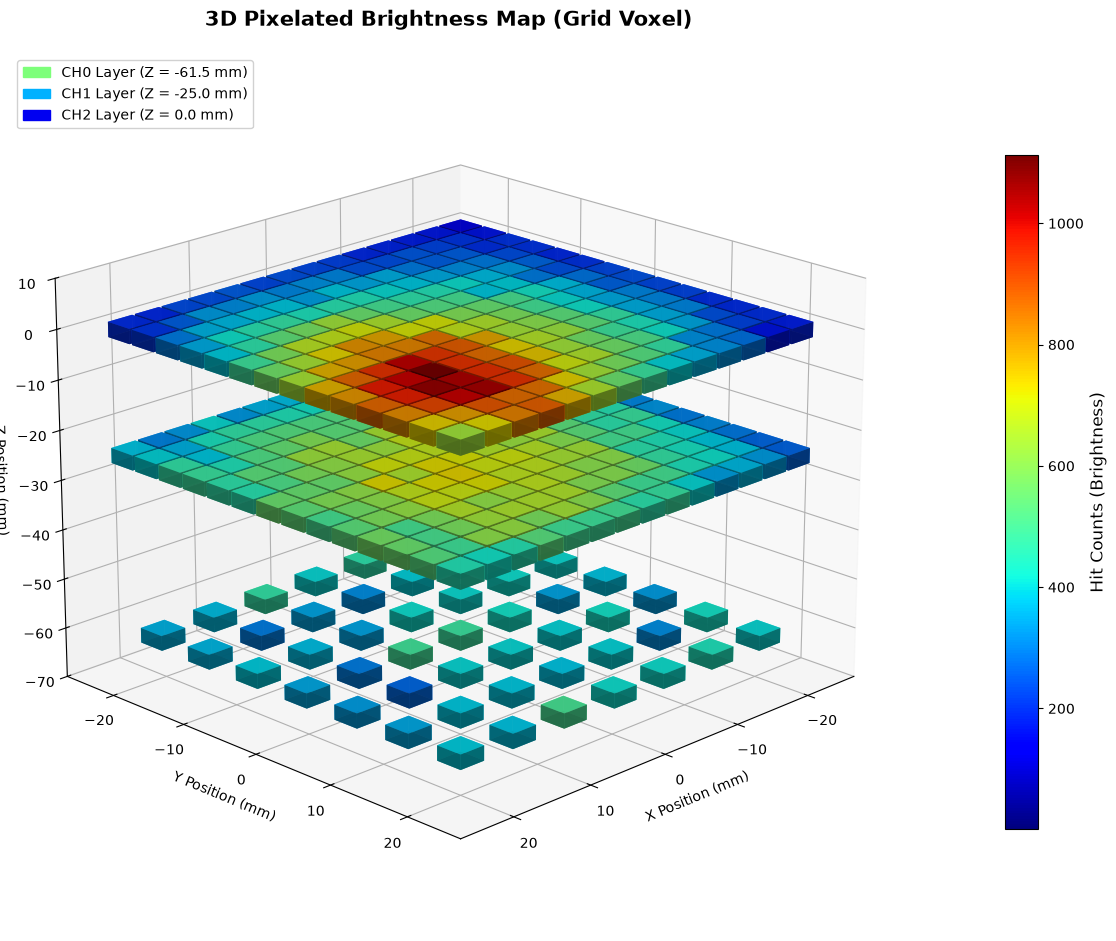

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# 1. 定义探测器真实的物理 Z 坐标映射
true_z_map = {
    'ch0': -61.5,
    'ch1': -25.0,
    'ch2': 0.0
}

# 创建 3D 画布
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

channels = ['ch0', 'ch1', 'ch2']
global_max_count = 1
pixel_data_list = []

# 2. 提取非空像素并计算亮度 (计数)
for i, ch in enumerate(channels):
    # 筛选有效事件 (能量 > 0)
    mask = final_df[f'{ch}_energy'] > 0
    df_valid = final_df[mask]
    
    if not df_valid.empty:
        # 按 x, y 分组统计
        pixel_counts = df_valid.groupby([f'{ch}_x', f'{ch}_y']).size().reset_index(name='counts')
        pixel_data_list.append(pixel_counts)
        global_max_count = max(global_max_count, pixel_counts['counts'].max())
    else:
        pixel_data_list.append(None)

# ================= 核心修改区：准备颜色与像素几何尺寸 =================

# 设置颜色映射器 (ScalarMappable)
cmap = plt.get_cmap('jet')
norm = mcolors.Normalize(vmin=1, vmax=global_max_count)

# 【重要参数】这里定义你探测器单个像素的长宽。
# 我根据常见的硅像素探测器预设了 1.5mm，请根据你实际的探测器 pixel pitch 进行修改！
pixel_dx = 3  # X方向像素宽度 (mm)
pixel_dy = 3  # Y方向像素宽度 (mm)
pixel_dz = 3  # 渲染出的像素块的厚度 (让它看起来像薄薄的一片)

# ====================================================================

# 3. 逐层绘制 3D 像素网格 (Voxel/Bar3D)
legend_patches = [] # 用于手动生成图例

for i, ch in enumerate(channels):
    pixel_counts = pixel_data_list[i]
    if pixel_counts is None or pixel_counts.empty:
        continue
        
    x_center = pixel_counts[f'{ch}_x'].values
    y_center = pixel_counts[f'{ch}_y'].values
    counts = pixel_counts['counts'].values
    
    real_z_val = true_z_map[ch]
    
    # bar3d 需要的是方块的“左下角”起始坐标，因此要用中心坐标减去尺寸的一半
    x_pos = x_center - pixel_dx / 2
    y_pos = y_center - pixel_dy / 2
    z_pos = np.full_like(x_center, real_z_val - pixel_dz / 2, dtype=float)
    
    # 每个方块的长、宽、高
    dx = np.full_like(x_center, pixel_dx, dtype=float)
    dy = np.full_like(x_center, pixel_dy, dtype=float)
    dz = np.full_like(x_center, pixel_dz, dtype=float)
    
    # 获取每个像素对应的颜色
    colors = cmap(norm(counts))
    
    # 画出 3D 像素块：shade=True 会开启 3D 光影质感，更有立体感
    ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=colors, alpha=0.9, shade=True)
    
    # 为每一层创建一个图例色块 (因为 bar3d 不能像 scatter 那样直接传 label 参数)
    # 取 cmap(0.5) 也就是绿色作为图例的底色
    legend_patches.append(mpatches.Patch(color=cmap(0.5 - i*0.2), label=f'{ch.upper()} Layer (Z = {real_z_val} mm)'))

# 4. 图表美化与视角调整
ax.set_title("3D Pixelated Brightness Map (Grid Voxel)", fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

ax.set_zlim(-70, 10)
ax.view_init(elev=20, azim=45)

# 绑定手动生成的图例
ax.legend(handles=legend_patches, loc='upper left', fontsize=10, framealpha=0.9)

# 生成独立的 Colorbar (因为 bar3d 不返回 Mappable 对象，需要单独构建)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Hit Counts (Brightness)', fontsize=12)

plt.tight_layout()
plt.show()

1. 从 final_df 中提取事件顶点、轴线与张角...
处理的双/三击中事件总数: 98753
因未落在全能峰 (0.64, 0.68) MeV 被剔除的事件: 85242
有效物理事件总数: 8656，抽取 8656 个事件画圆环...
2. 在 Z = 20.0 mm 平面上生成圆环轨迹...
3. 绘制重叠圆环图像...


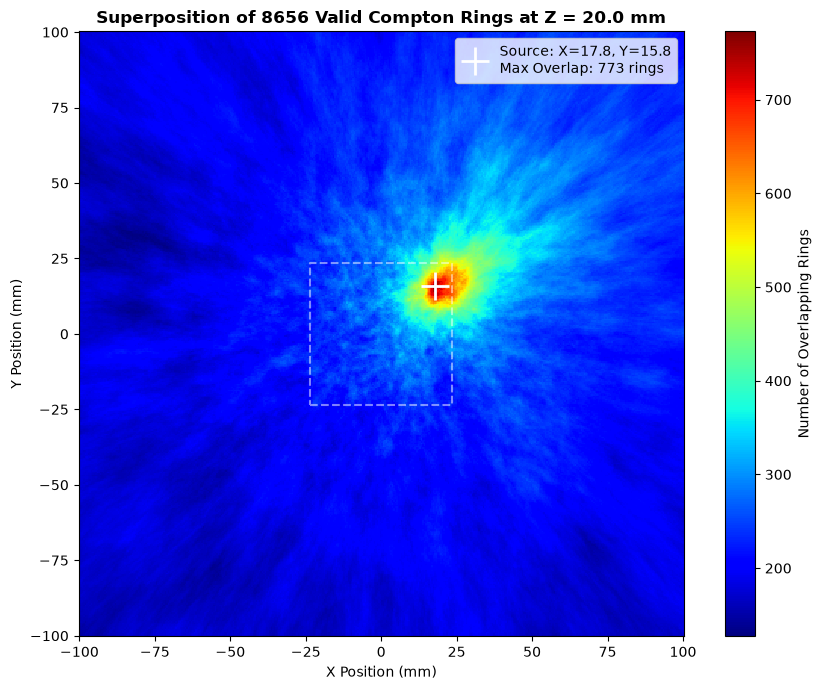

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##############此处将全吸收峰进行重建########
m_e = 0.511  # 电子静止质量 MeV

def reconstruct_overlapping_rings_from_df(df, Z_plane=50.0, resolution=400, fov=150.0, num_events=300, 
                                          energy_window=(0.60, 0.72)):
    print("1. 从 final_df 中提取事件顶点、轴线与张角...")
    
    r1_positions = []
    axes = []
    angles = []
    
    # 提取符合能量窗的事件数统计，方便你 Debug
    total_processed = 0
    energy_rejected = 0
    
    for row in df.itertuples(index=False):
        hits = []
        cols = df.columns
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if e_col in cols:
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    x = getattr(row, f'{ch}_x')
                    y = getattr(row, f'{ch}_y')
                    z = getattr(row, f'{ch}_z')
                    hits.append((x, y, z, e_val))
                    
        if len(hits) < 2:
            continue
            
        total_processed += 1
        E_total = sum(h[3] for h in hits)
        
        # ================== 核心修复 1：能量窗截断 ==================
        # 只有当总沉积能量位于全能峰(Photopeak)附近时，康普顿公式才成立！
        if not (energy_window[0] <= E_total <= energy_window[1]):
            energy_rejected += 1
            continue
            
        # ================== 核心修复 2：物理击中顺序 ==================
        # 假设放射源在前方 (Z > 0)，光子会先击中 Z 坐标大的探测器 (Z=0)，再击中 Z 坐标小的 (Z=-61.5)
        # 所以必须按照 Z 坐标 **降序(reverse=True)** 排列！
        # 注意：如果你的源放在了探测器后方(Z < -61.5)，请把 reverse 改回 False
        hits.sort(key=lambda item: item[2], reverse=True)
        
        p1 = hits[0] # 第一次作用 (康普顿散射)
        p2 = hits[1] # 第二次作用 (光电吸收或再次散射)
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = sum(h[3] for h in hits[1:]) 
        # 必须刚好是 2 次击中，并且 ch0 的能量是 0 或 NaN
        if len(hits) != 2 or (pd.notna(getattr(row, 'ch0_energy')) and getattr(row, 'ch0_energy') > 0):
            continue
        # 轴线向量：从 p2 指向 p1 (即指向源的方向)
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0:
            continue
        axis = vec / norm
        
        # 康普顿散射公式
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    r1_positions = np.array(r1_positions)
    axes = np.array(axes)
    angles = np.array(angles)
    
    total_valid = len(axes)
    print(f"处理的双/三击中事件总数: {total_processed}")
    print(f"因未落在全能峰 {energy_window} MeV 被剔除的事件: {energy_rejected}")
    
    if total_valid == 0:
        print("没有找到符合物理规律的康普顿散射事件！请检查能量刻度或能量窗。")
        return
        
    plot_num = min(total_valid, num_events)
    print(f"有效物理事件总数: {total_valid}，抽取 {plot_num} 个事件画圆环...")

    print(f"2. 在 Z = {Z_plane} mm 平面上生成圆环轨迹...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    ZZ = np.full_like(XX, Z_plane)
    
    grid_points = np.stack((XX.flatten(), YY.flatten(), ZZ.flatten()), axis=1)
    image_array = np.zeros(len(grid_points))

    # 线条容差：太细容易没有交点，太粗分辨率低。1.5~2.5 度较合适
    line_thickness = np.radians(1.5) 

    for i in range(plot_num):
        r1 = r1_positions[i]
        v_axis = axes[i]
        theta_expected = angles[i]

        v_pixel = grid_points - r1
        v_pixel_norms = np.linalg.norm(v_pixel, axis=1)
        
        valid = v_pixel_norms > 0
        cos_alpha = np.zeros_like(v_pixel_norms)
        cos_alpha[valid] = np.dot(v_pixel[valid], v_axis) / v_pixel_norms[valid]
        cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
        alpha = np.arccos(cos_alpha)
        
        hit_mask = np.abs(alpha - theta_expected) < line_thickness
        image_array[hit_mask] += 1

    print("3. 绘制重叠圆环图像...")
    image_2d = image_array.reshape((resolution, resolution))
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x = X[max_idx[1]]
    peak_y = Y[max_idx[0]]
    max_overlap = int(np.max(image_2d))

    plt.figure(figsize=(9, 7))
    im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    
    plt.plot(peak_x, peak_y, 'w+', markersize=20, markeredgewidth=2, 
             label=f'Source: X={peak_x:.1f}, Y={peak_y:.1f}\nMax Overlap: {max_overlap} rings')
    
    plt.title(f"Superposition of {plot_num} Valid Compton Rings at Z = {Z_plane} mm", fontweight='bold')
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.colorbar(im, label='Number of Overlapping Rings')
    plt.legend(loc='upper right')
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
             [-det_size, -det_size, det_size, det_size, -det_size], 
             'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # ================= 注意检查这里的参数 =================
    # 假设你的放射源放在距离 ch2 表面 50mm 的正前方
    ACTUAL_SOURCE_Z = 20.0 
    
    reconstruct_overlapping_rings_from_df(
        df=final_df, 
        Z_plane=ACTUAL_SOURCE_Z,      # 【必须修改为你实验中放射源的真实 Z 坐标】
        resolution=400, 
        fov=100.0, 
        num_events=100000,               # 过滤后事件变少，可以适当增加画图数量
        energy_window=(0.64, 0.68)    # Cs-137 0.662 MeV 峰的能量窗
    )

1. 正在提取事件并计算 ARM (假定源位置: (16, 13, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


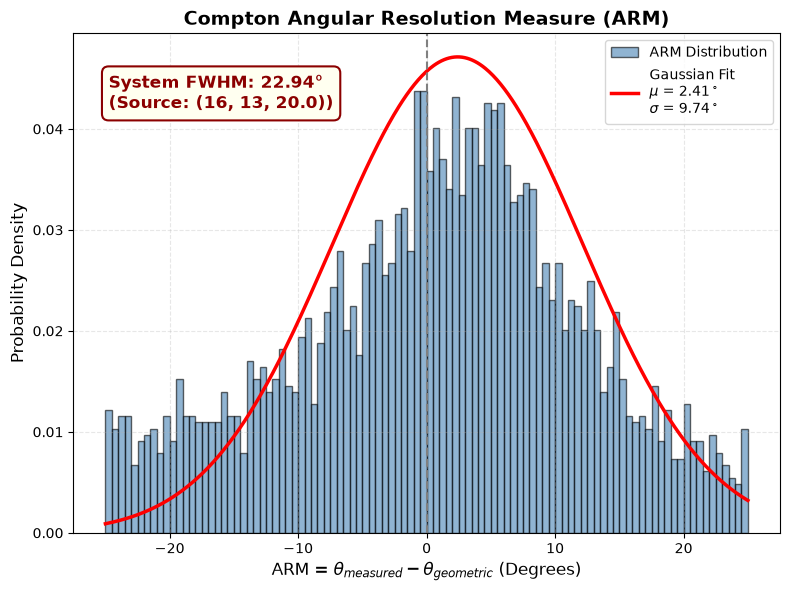

1. 正在提取事件并计算 ARM (假定源位置: (16, 14, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


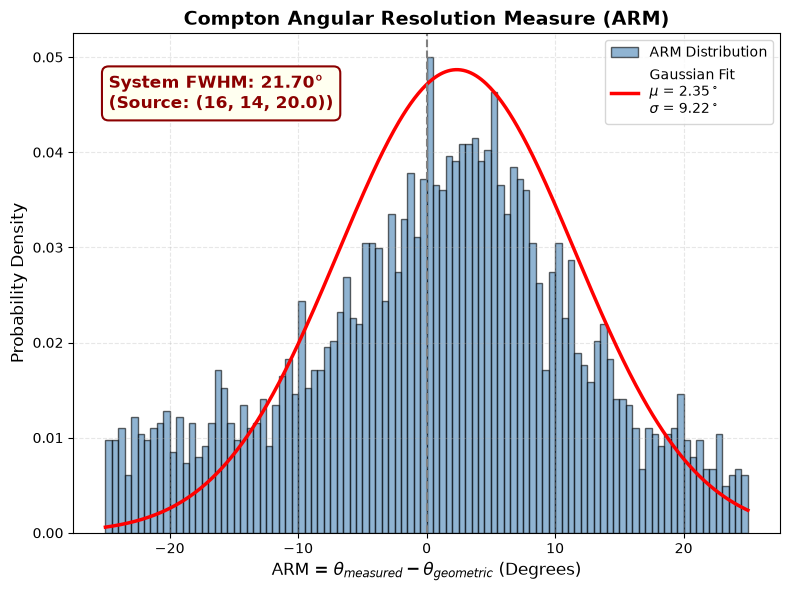

1. 正在提取事件并计算 ARM (假定源位置: (16, 15, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


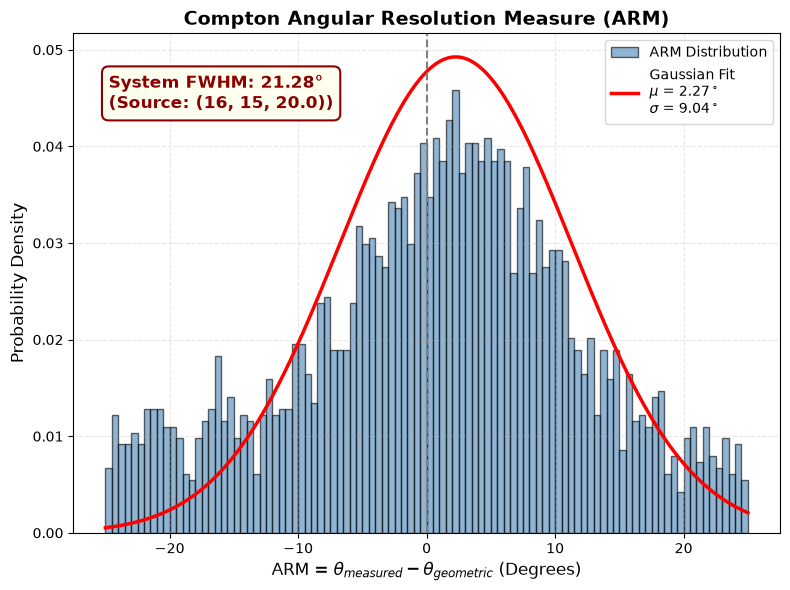

1. 正在提取事件并计算 ARM (假定源位置: (16, 16, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


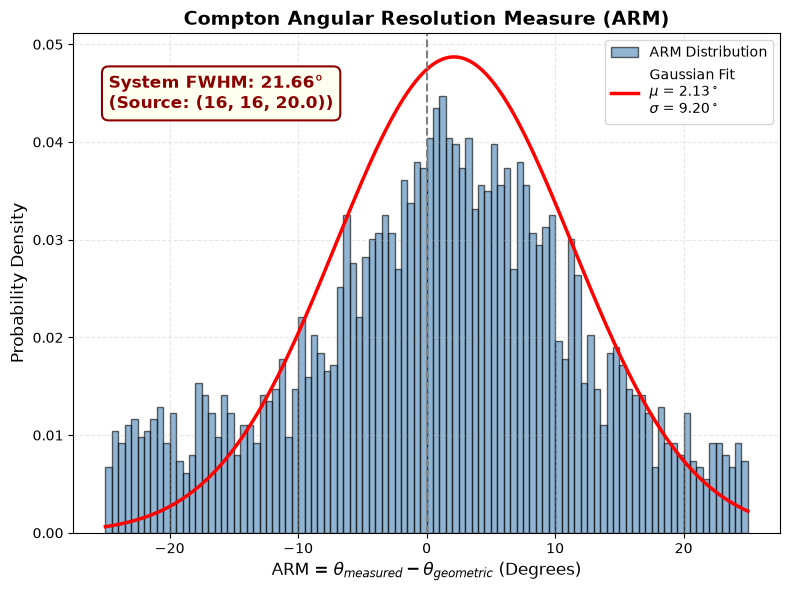

1. 正在提取事件并计算 ARM (假定源位置: (17, 13, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


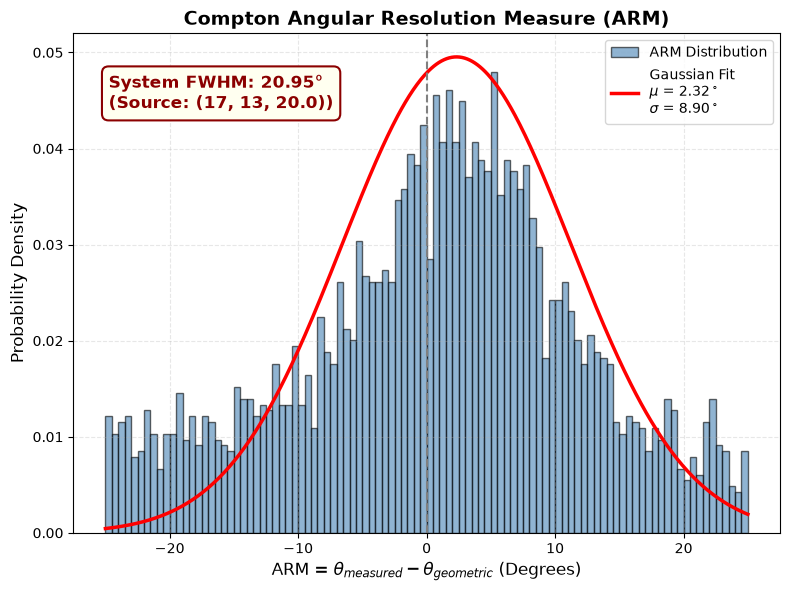

1. 正在提取事件并计算 ARM (假定源位置: (17, 14, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


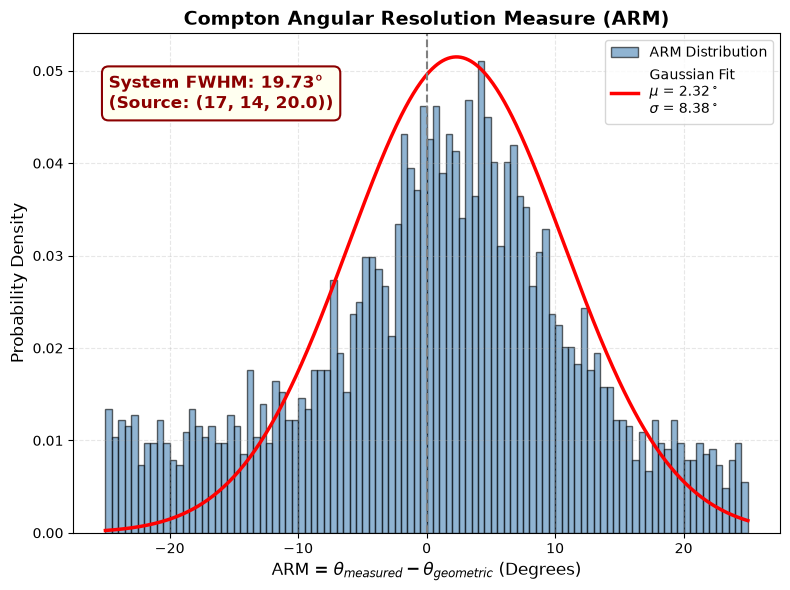

1. 正在提取事件并计算 ARM (假定源位置: (17, 15, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


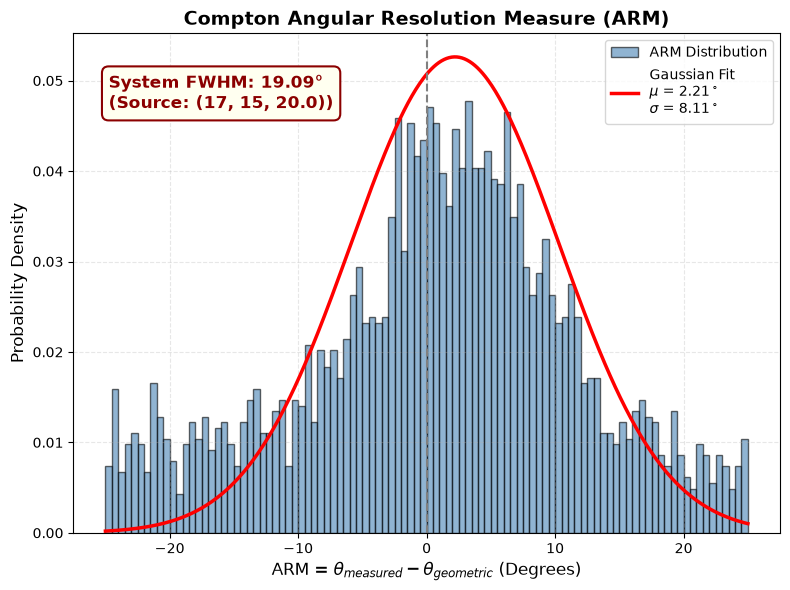

1. 正在提取事件并计算 ARM (假定源位置: (17, 16, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


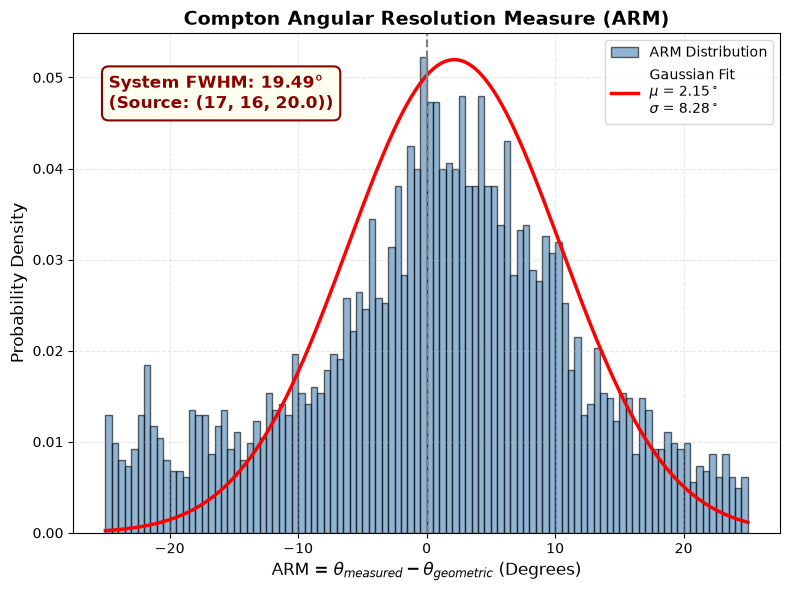

1. 正在提取事件并计算 ARM (假定源位置: (18, 13, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


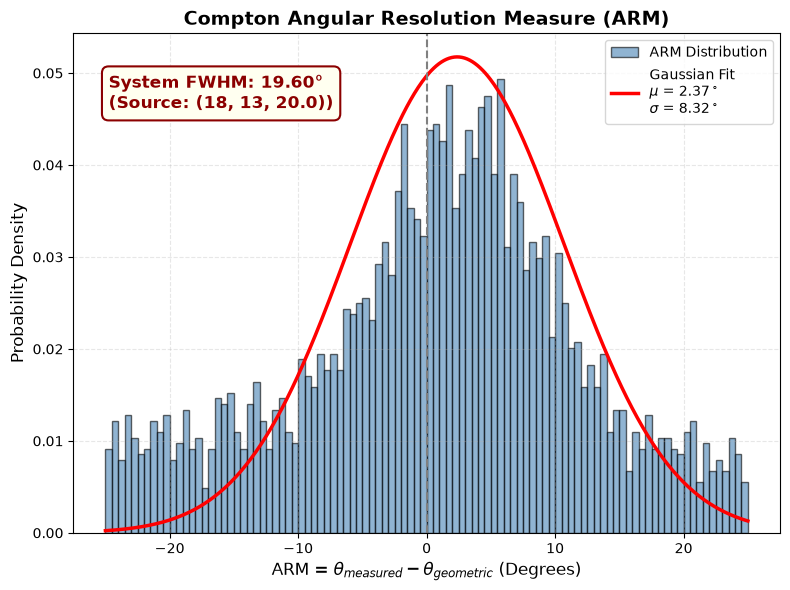

1. 正在提取事件并计算 ARM (假定源位置: (18, 14, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


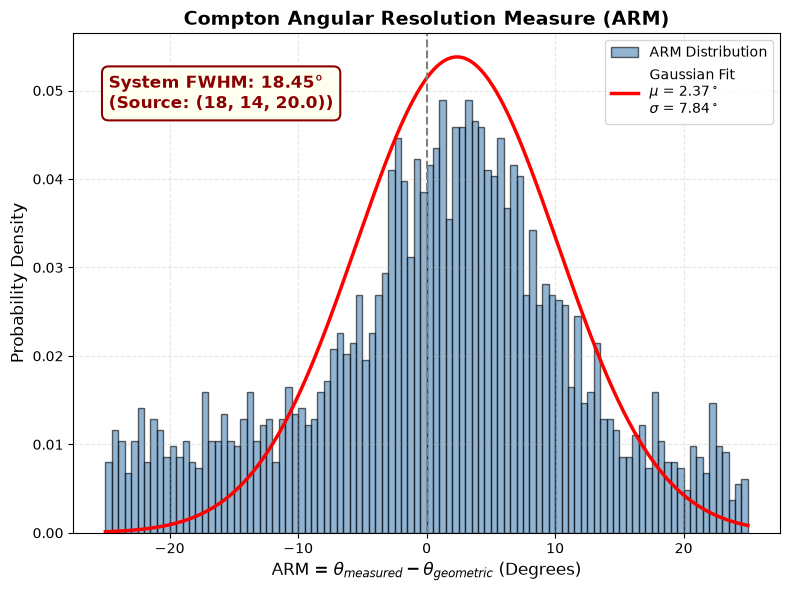

1. 正在提取事件并计算 ARM (假定源位置: (18, 15, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


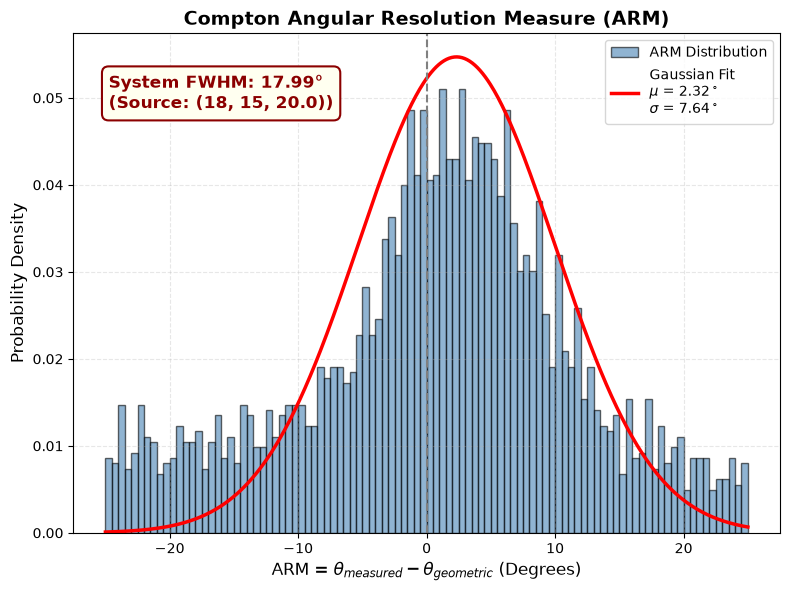

1. 正在提取事件并计算 ARM (假定源位置: (18, 16, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


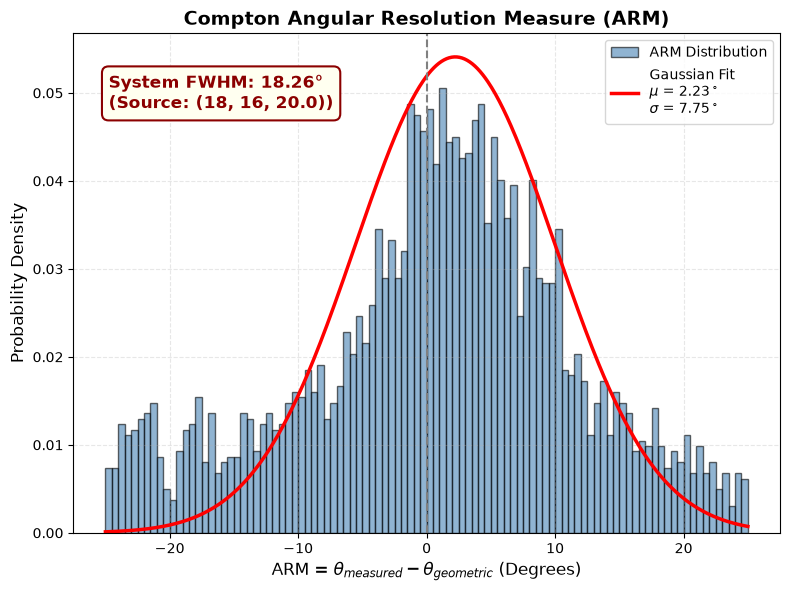

1. 正在提取事件并计算 ARM (假定源位置: (19, 13, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


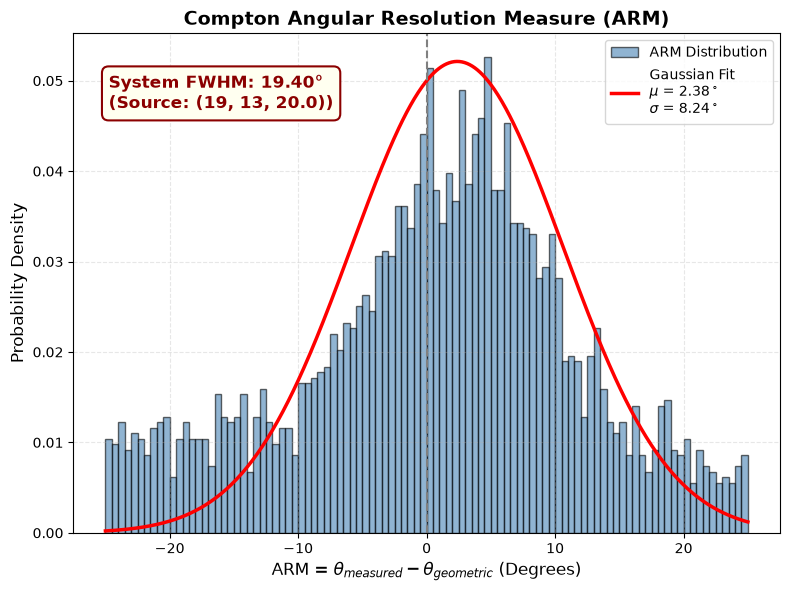

1. 正在提取事件并计算 ARM (假定源位置: (19, 14, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


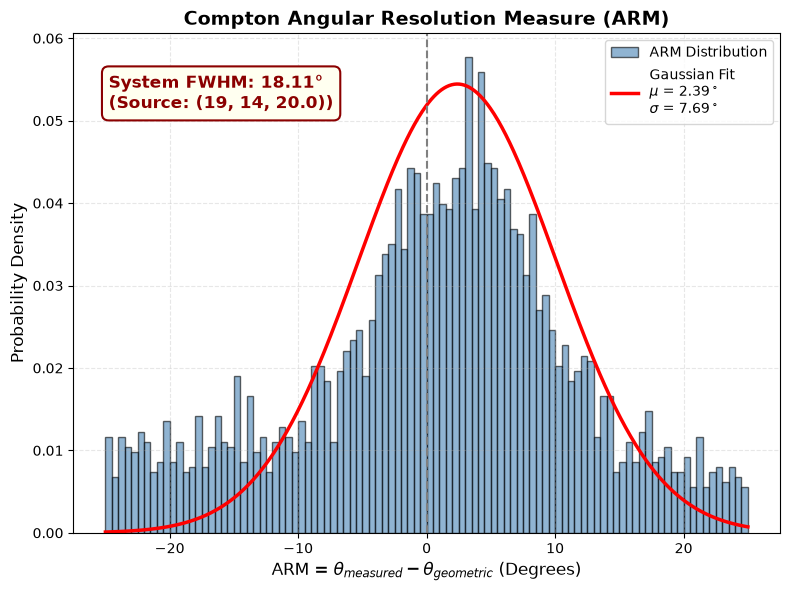

1. 正在提取事件并计算 ARM (假定源位置: (19, 15, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


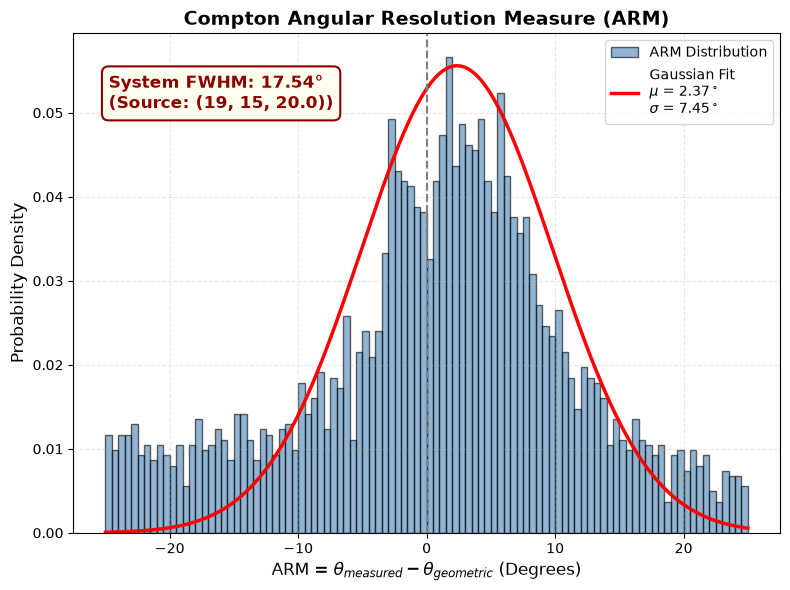

1. 正在提取事件并计算 ARM (假定源位置: (19, 16, 20.0))...
✅ 成功计算 4852 个事件的 ARM。正在进行高斯拟合...


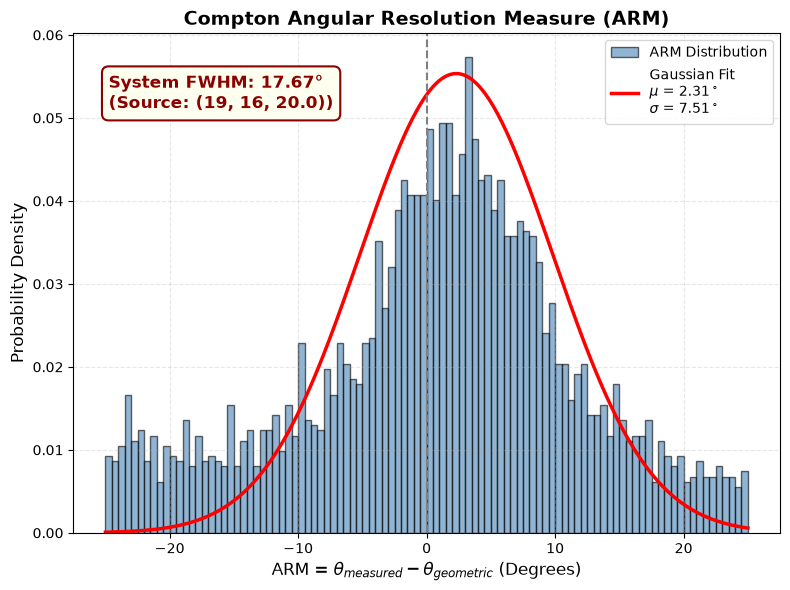


💡 提示：你可以将计算出的 sigma 值 (7.51) 填入 MLEM 算法的 sigma_deg 参数中，以获得最佳成像分辨率。


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_and_plot_arm(df, source_pos=(0.0, 0.0, 20.0), energy_window=(0.64, 0.68)):
    """
    利用与 MLEM 相同的逻辑提取数据，并计算系统的角度分辨率 (ARM)
    
    参数:
    - df: 包含事件的 DataFrame
    - source_pos: 真实放射源的三维坐标 (X, Y, Z)，默认 (0, 0, 20.0) mm
    - energy_window: 总能量筛选窗口
    """
    m_e = 0.511  # MeV
    src = np.array(source_pos)
    arm_list = []
    
    print(f"1. 正在提取事件并计算 ARM (假定源位置: {source_pos})...")
    
    # 保持与 MLEM 完全一致的数据读取和过滤逻辑
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按 Z 坐标降序排列
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        E2_total = p2[3] 
        
        # ---------------- 核心 ARM 计算 ----------------
        # 1. 测量散射角 (由能量反推)
        cos_theta_meas = 1 - m_e * (1 / E2_total - 1 / E_total)
        if not (-1 <= cos_theta_meas <= 1):
            continue
        theta_meas = np.arccos(cos_theta_meas)
        
        # 2. 几何真实散射角 (由源位置和相互作用点计算)
        vec_in = pos1 - src        # 入射光子方向向量
        vec_out = pos2 - pos1      # 散射光子方向向量
        
        norm_in = np.linalg.norm(vec_in)
        norm_out = np.linalg.norm(vec_out)
        
        if norm_in == 0 or norm_out == 0:
            continue
            
        # 计算两个向量的夹角
        cos_theta_geo = np.dot(vec_in, vec_out) / (norm_in * norm_out)
        cos_theta_geo = np.clip(cos_theta_geo, -1.0, 1.0)
        theta_geo = np.arccos(cos_theta_geo)
        
        # 3. 计算 ARM = Theta_测量 - Theta_几何 (转换为角度)
        arm_deg = np.degrees(theta_meas - theta_geo)
        arm_list.append(arm_deg)

    arm_array = np.array(arm_list)
    if len(arm_array) == 0:
        print("❌ 错误：没有提取到任何有效事件，无法计算 ARM。")
        return

    print(f"✅ 成功计算 {len(arm_array)} 个事件的 ARM。正在进行高斯拟合...")

    # ---------------- 统计与高斯拟合 ----------------
    # 限制拟合范围，防止极端的本底噪声拉偏曲线
    fit_range = (-15, 15)
    filtered_arm = arm_array[(arm_array >= fit_range[0]) & (arm_array <= fit_range[1])]
    
    counts, bin_edges = np.histogram(filtered_arm, bins=60, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 定义高斯函数
    def gauss(x, a, mu, sigma):
        return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

    # 初始猜测参数
    p0 = [np.max(counts), 0.0, 3.0]
    
    try:
        popt, _ = curve_fit(gauss, bin_centers, counts, p0=p0)
        fit_mu, fit_sigma = popt[1], abs(popt[2])
        fwhm = 2.355 * fit_sigma
        fit_success = True
    except:
        print("⚠️ 高斯拟合失败，使用常规统计标准差代替。")
        fit_success = False
        fit_mu = np.mean(filtered_arm)
        fit_sigma = np.std(filtered_arm)
        fwhm = 2.355 * fit_sigma

    # ---------------- 绘制结果 ----------------
    plt.figure(figsize=(8, 6))
    
    # 画直方图
    plt.hist(arm_array, bins=100, range=(-25, 25), density=True, 
             alpha=0.6, color='steelblue', edgecolor='black', label='ARM Distribution')
    
    # 画拟合曲线
    if fit_success:
        x_fit = np.linspace(-25, 25, 500)
        plt.plot(x_fit, gauss(x_fit, *popt), 'r-', lw=2.5, 
                 label=f'Gaussian Fit\n$\mu$ = {fit_mu:.2f}$^\circ$\n$\sigma$ = {fit_sigma:.2f}$^\circ$')
        
    plt.axvline(0, color='gray', linestyle='--', lw=1.5)
    
    # 添加高亮文本框显示 FWHM
    bbox_props = dict(boxstyle="round,pad=0.4", fc="ivory", ec="darkred", lw=1.5)
    plt.text(0.05, 0.85, f"System FWHM: {fwhm:.2f}°\n(Source: {source_pos})", 
             transform=plt.gca().transAxes, fontsize=12, fontweight='bold', 
             color='darkred', bbox=bbox_props)

    plt.title(f"Compton Angular Resolution Measure (ARM)", fontweight='bold', fontsize=14)
    plt.xlabel(r"ARM = $\theta_{measured} - \theta_{geometric}$ (Degrees)", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    return fwhm, fit_sigma

# ================= 调用示例 =================
if __name__ == "__main__":
    # 你可以随时修改 source_pos 为你模拟或实验中真实的放射源位置
    # 比如在你的 MLEM 图片中，源似乎在 (-20, 15) 附近
    for  x in range(16,20):
        for y in range(13,17):
            calculated_fwhm, calculated_sigma = calculate_and_plot_arm(
                df=final_df, 
                source_pos=(x, y, 20.0),  # <--- 在这里输入真实的源坐标 (X, Y, Z)
                energy_window=(0.652, 0.672)
            )
    
    print(f"\n💡 提示：你可以将计算出的 sigma 值 ({calculated_sigma:.2f}) 填入 MLEM 算法的 sigma_deg 参数中，以获得最佳成像分辨率。")

1. 正在提取和筛选康普顿事件...
✅ 成功提取 8656 个有效事件。
2. 初始化 Z = 20.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 8188/8656 | 图像峰值: 4.52e-01
   - 迭代 2/15 | 参与事件: 8188/8656 | 图像峰值: 1.20e+00
   - 迭代 3/15 | 参与事件: 8188/8656 | 图像峰值: 2.58e+00
   - 迭代 4/15 | 参与事件: 8188/8656 | 图像峰值: 4.56e+00
   - 迭代 5/15 | 参与事件: 8188/8656 | 图像峰值: 6.78e+00
   - 迭代 6/15 | 参与事件: 8188/8656 | 图像峰值: 8.83e+00
   - 迭代 7/15 | 参与事件: 8188/8656 | 图像峰值: 1.05e+01
   - 迭代 8/15 | 参与事件: 8188/8656 | 图像峰值: 1.18e+01
   - 迭代 9/15 | 参与事件: 8188/8656 | 图像峰值: 1.28e+01
   - 迭代 10/15 | 参与事件: 8188/8656 | 图像峰值: 1.36e+01
   - 迭代 11/15 | 参与事件: 8188/8656 | 图像峰值: 1.42e+01
   - 迭代 12/15 | 参与事件: 8188/8656 | 图像峰值: 1.48e+01
   - 迭代 13/15 | 参与事件: 8188/8656 | 图像峰值: 1.52e+01
   - 迭代 14/15 | 参与事件: 8188/8656 | 图像峰值: 1.56e+01
   - 迭代 15/15 | 参与事件: 8188/8656 | 图像峰值: 1.59e+01
迭代完成，耗时: 584.40 秒
4. 绘制 MLEM 重建结果...


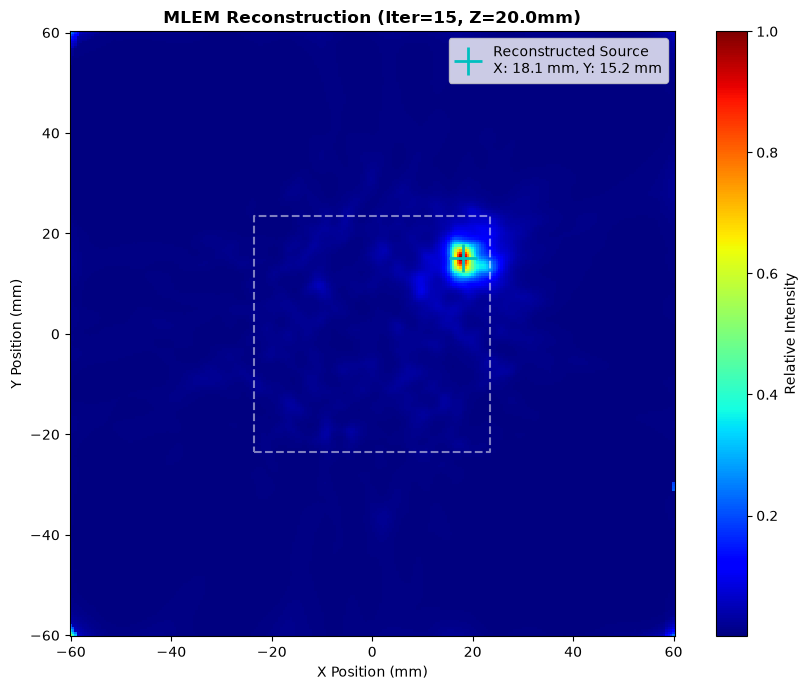

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
    print("1. 正在提取和筛选康普顿事件...")
    r1_positions, axes, angles = [], [], []
    
    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = p2[3] 
        
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {plot_num} 个有效事件。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式 (移除错误的自身敏感度惩罚)
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")

    print("4. 绘制 MLEM 重建结果...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    plt.figure(figsize=(9, 7))
    # 推荐使用 'hot' 或 'jet'，'hot' 对高亮点的对比度更好
    im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    plt.plot(peak_x, peak_y, 'c+', markersize=20, markeredgewidth=2, 
             label=f'Reconstructed Source\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    plt.title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.colorbar(im, label='Relative Intensity')
    plt.legend(loc='upper right')
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
             [-det_size, -det_size, det_size, det_size, -det_size], 
             'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# 调用示例
if __name__ == "__main__":
    # 假设你已经有了 final_df 数据
    reconstruct_mlem_v3(
        df=final_df, 
        Z_plane=20.0,            # 请确保这是真实的放射源 Z 距离
        resolution=250,          # 提高分辨率让图像更平滑
        fov=60.0,                # 探测器本身只有 47x47mm，FOV 设为 60 足够覆盖全貌
        num_events=100000,         # 增加事件数以提高信噪比
        energy_window=(0.64, 0.68), 
        iterations=15,           # 强烈建议迭代 10 - 15 次，效果最佳
        sigma_deg=2.5            # 适配 3.36mm 像素的高斯平滑度 (推荐 2.5 ~ 3.5 之间微调)
    )

1. 正在提取和筛选康普顿事件...
✅ 成功提取 4852 个有效事件。
2. 初始化 Z = 20.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 4732/4852 | 图像峰值: 3.25e-01
   - 迭代 2/15 | 参与事件: 4732/4852 | 图像峰值: 6.13e-01
   - 迭代 3/15 | 参与事件: 4732/4852 | 图像峰值: 8.88e-01
   - 迭代 4/15 | 参与事件: 4732/4852 | 图像峰值: 1.13e+00
   - 迭代 5/15 | 参与事件: 4732/4852 | 图像峰值: 1.51e+00
   - 迭代 6/15 | 参与事件: 4732/4852 | 图像峰值: 2.11e+00
   - 迭代 7/15 | 参与事件: 4732/4852 | 图像峰值: 2.78e+00
   - 迭代 8/15 | 参与事件: 4732/4852 | 图像峰值: 3.47e+00
   - 迭代 9/15 | 参与事件: 4732/4852 | 图像峰值: 4.15e+00
   - 迭代 10/15 | 参与事件: 4732/4852 | 图像峰值: 4.82e+00
   - 迭代 11/15 | 参与事件: 4732/4852 | 图像峰值: 5.45e+00
   - 迭代 12/15 | 参与事件: 4732/4852 | 图像峰值: 6.05e+00
   - 迭代 13/15 | 参与事件: 4732/4852 | 图像峰值: 6.61e+00
   - 迭代 14/15 | 参与事件: 4732/4852 | 图像峰值: 7.13e+00
   - 迭代 15/15 | 参与事件: 4732/4852 | 图像峰值: 7.63e+00
迭代完成，耗时: 322.55 秒
4. 绘制 MLEM 重建结果...


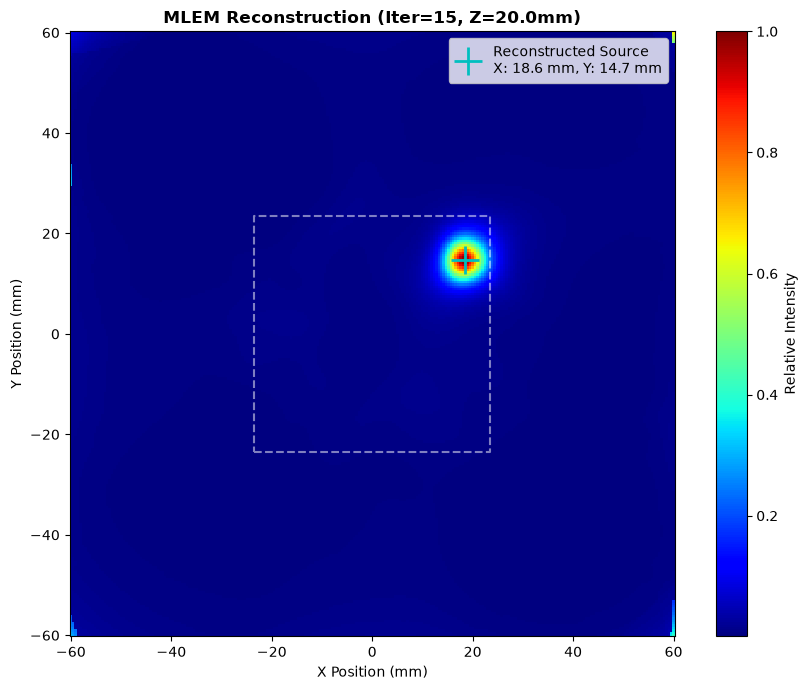

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
    print("1. 正在提取和筛选康普顿事件...")
    r1_positions, axes, angles = [], [], []
    
    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = p2[3] 
        
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {plot_num} 个有效事件。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式 (移除错误的自身敏感度惩罚)
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")

    print("4. 绘制 MLEM 重建结果...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    plt.figure(figsize=(9, 7))
    # 推荐使用 'hot' 或 'jet'，'hot' 对高亮点的对比度更好
    im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    plt.plot(peak_x, peak_y, 'c+', markersize=20, markeredgewidth=2, 
             label=f'Reconstructed Source\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    plt.title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.colorbar(im, label='Relative Intensity')
    plt.legend(loc='upper right')
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
             [-det_size, -det_size, det_size, det_size, -det_size], 
             'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# 调用示例
if __name__ == "__main__":
    # 假设你已经有了 final_df 数据
    reconstruct_mlem_v3(
        df=final_df, 
        Z_plane=20.0,            # 请确保这是真实的放射源 Z 距离
        resolution=250,          # 提高分辨率让图像更平滑
        fov=60.0,                # 探测器本身只有 47x47mm，FOV 设为 60 足够覆盖全貌
        num_events=100000,         # 增加事件数以提高信噪比
        energy_window=(0.652, 0.672), 
        iterations=15,           # 强烈建议迭代 10 - 15 次，效果最佳
        sigma_deg=8.0            # 适配 3.36mm 像素的高斯平滑度 (推荐 2.5 ~ 3.5 之间微调)
    )

1. 正在提取和筛选康普顿事件...
✅ 成功提取 4852 个有效事件。
2. 初始化 Z = 20.0 mm 平面网格...
3. 开始 List-Mode MLEM 迭代 (15 次)...
   - 迭代 1/15 | 参与事件: 4738/4852 | 图像峰值: 2.10e-01
   - 迭代 2/15 | 参与事件: 4738/4852 | 图像峰值: 3.70e-01
   - 迭代 3/15 | 参与事件: 4738/4852 | 图像峰值: 6.01e-01
   - 迭代 4/15 | 参与事件: 4738/4852 | 图像峰值: 9.63e-01
   - 迭代 5/15 | 参与事件: 4738/4852 | 图像峰值: 1.43e+00
   - 迭代 6/15 | 参与事件: 4738/4852 | 图像峰值: 2.00e+00
   - 迭代 7/15 | 参与事件: 4738/4852 | 图像峰值: 2.62e+00
   - 迭代 8/15 | 参与事件: 4738/4852 | 图像峰值: 3.29e+00
   - 迭代 9/15 | 参与事件: 4738/4852 | 图像峰值: 3.95e+00
   - 迭代 10/15 | 参与事件: 4738/4852 | 图像峰值: 4.60e+00
   - 迭代 11/15 | 参与事件: 4738/4852 | 图像峰值: 5.22e+00
   - 迭代 12/15 | 参与事件: 4738/4852 | 图像峰值: 5.81e+00
   - 迭代 13/15 | 参与事件: 4738/4852 | 图像峰值: 6.36e+00
   - 迭代 14/15 | 参与事件: 4738/4852 | 图像峰值: 6.88e+00
   - 迭代 15/15 | 参与事件: 4738/4852 | 图像峰值: 7.37e+00
迭代完成，耗时: 321.08 秒
4. 绘制 MLEM 重建结果...


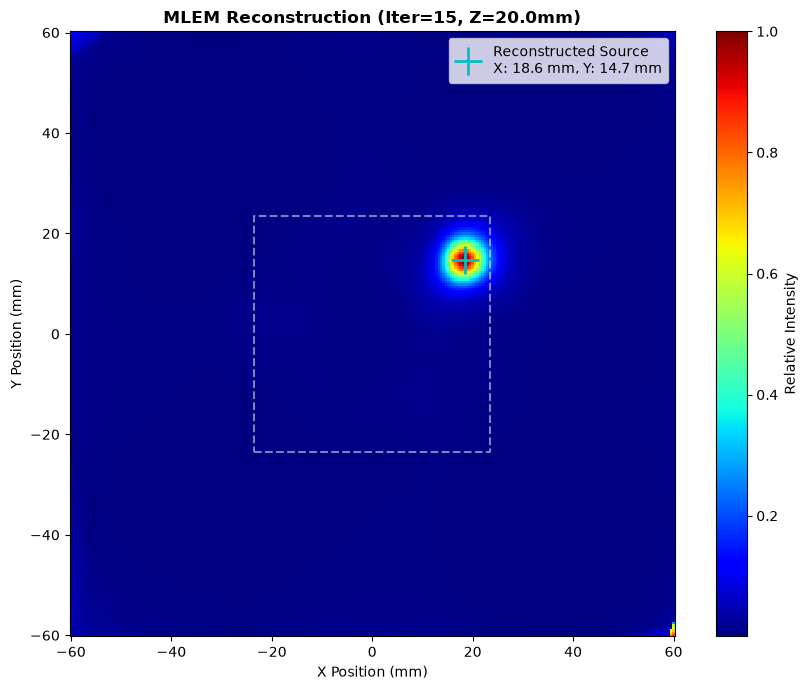

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

m_e = 0.511  # 电子静止质量 MeV

def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
                        energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
    print("1. 正在提取和筛选康普顿事件...")
    r1_positions, axes, angles = [], [], []
    
    # 提取并计算物理参量
    for row in df.itertuples(index=False):
        hits = []
        for ch in ['ch0', 'ch1', 'ch2']:
            e_col = f'{ch}_energy'
            if hasattr(row, e_col):
                e_val = getattr(row, e_col)
                if pd.notna(e_val) and e_val > 0:
                    hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
        if len(hits) != 2:
            continue
            
        E_total = sum(h[3] for h in hits)
        if not (energy_window[0] <= E_total <= energy_window[1]):
            continue
            
        # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
        hits.sort(key=lambda item: item[2], reverse=True)
        p1, p2 = hits[0], hits[1]
        
        pos1 = np.array([p1[0], p1[1], p1[2]])
        pos2 = np.array([p2[0], p2[1], p2[2]])
        
        E2_total = p2[3] 
        
        vec = pos1 - pos2
        norm = np.linalg.norm(vec)
        if norm == 0: continue
        axis = vec / norm
        
        cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
        if -1 <= cos_theta <= 1:
            r1_positions.append(pos1)
            axes.append(axis)
            angles.append(np.arccos(cos_theta))

    plot_num = min(len(axes), num_events)
    if plot_num == 0:
        print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
        return
        
    print(f"✅ 成功提取 {plot_num} 个有效事件。")

    print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
    X = np.linspace(-fov, fov, resolution)
    Y = np.linspace(-fov, fov, resolution)
    XX, YY = np.meshgrid(X, Y)
    grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
    # 初始化图像为均匀分布
    image_mlem = np.ones(len(grid_points)) 
    sigma_rad = np.radians(sigma_deg)

    print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
    start_time = time.time()
    
    for it in range(iterations):
        update_factor = np.zeros(len(grid_points))
        valid_events_this_iter = 0
        
        for i in range(plot_num):
            v_pixel = grid_points - r1_positions[i]
            v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
            cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
            cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
            alpha = np.arccos(cos_alpha)
            
            # 高斯概率响应
            t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
            t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
            # 投影期望值 F_i
            F_i = np.sum(t_i * image_mlem)
            
            # 累加更新因子 (只有 F_i 足够大时才更新)
            if F_i > 1e-12:
                update_factor += t_i / F_i
                valid_events_this_iter += 1
                
        # 纯净版 MLEM 更新公式 (移除错误的自身敏感度惩罚)
        image_mlem = image_mlem * update_factor
        
        # 打印监控
        max_val = np.max(image_mlem)
        print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

    print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")

    print("4. 绘制 MLEM 重建结果...")
    image_2d = image_mlem.reshape((resolution, resolution))
    
    # 归一化显示
    image_2d = image_2d / np.max(image_2d) 
    
    max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
    peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

    plt.figure(figsize=(9, 7))
    # 推荐使用 'hot' 或 'jet'，'hot' 对高亮点的对比度更好
    im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
    plt.plot(peak_x, peak_y, 'c+', markersize=20, markeredgewidth=2, 
             label=f'Reconstructed Source\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
    plt.title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
    plt.xlabel("X Position (mm)")
    plt.ylabel("Y Position (mm)")
    plt.colorbar(im, label='Relative Intensity')
    plt.legend(loc='upper right')
    
    # 绘制探测器的物理边界参考框 (47mm x 47mm)
    det_size = 14 * 3.36 / 2
    plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
             [-det_size, -det_size, det_size, det_size, -det_size], 
             'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.show()

# 调用示例
if __name__ == "__main__":
    # 假设你已经有了 final_df 数据
    reconstruct_mlem_v3(
        df=final_df, 
        Z_plane=20.0,            # 请确保这是真实的放射源 Z 距离
        resolution=250,          # 提高分辨率让图像更平滑
        fov=60.0,                # 探测器本身只有 47x47mm，FOV 设为 60 足够覆盖全貌
        num_events=100000,         # 增加事件数以提高信噪比
        energy_window=(0.652, 0.672), 
        iterations=15,           # 强烈建议迭代 10 - 15 次，效果最佳
        sigma_deg=8.3            # 适配 3.36mm 像素的高斯平滑度 (推荐 2.5 ~ 3.5 之间微调)
    )

In [16]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import time

# m_e = 0.511  # 电子静止质量 MeV

# def reconstruct_mlem_v3(df, Z_plane=50.0, resolution=200, fov=60.0, num_events=500, 
#                         energy_window=(0.60, 0.72), iterations=10, sigma_deg=3.0):
    
#     print("1. 正在提取和筛选康普顿事件...")
#     r1_positions, axes, angles = [], [], []
    
#     # 提取并计算物理参量
#     for row in df.itertuples(index=False):
#         hits = []
#         for ch in ['ch0', 'ch1', 'ch2']:
#             e_col = f'{ch}_energy'
#             if hasattr(row, e_col):
#                 e_val = getattr(row, e_col)
#                 if pd.notna(e_val) and e_val > 0:
#                     hits.append((getattr(row, f'{ch}_x'), getattr(row, f'{ch}_y'), getattr(row, f'{ch}_z'), e_val))
                    
#         if len(hits) != 2:
#             continue
            
#         E_total = sum(h[3] for h in hits)
#         if not (energy_window[0] <= E_total <= energy_window[1]):
#             continue
            
#         # 按照 Z 坐标降序排列，确保物理因果律 (假设源在正前方 Z > 0)
#         hits.sort(key=lambda item: item[2], reverse=True)
#         p1, p2 = hits[0], hits[1]
        
#         pos1 = np.array([p1[0], p1[1], p1[2]])
#         pos2 = np.array([p2[0], p2[1], p2[2]])
        
#         E2_total = p2[3] 
        
#         vec = pos1 - pos2
#         norm = np.linalg.norm(vec)
#         if norm == 0: continue
#         axis = vec / norm
        
#         cos_theta = 1 - m_e * (1 / E2_total - 1 / E_total)
#         if -1 <= cos_theta <= 1:
#             r1_positions.append(pos1)
#             axes.append(axis)
#             angles.append(np.arccos(cos_theta))

#     plot_num = min(len(axes), num_events)
#     if plot_num == 0:
#         print("❌ 错误：没有提取到任何有效事件，请检查 final_df 数据格式或能量窗！")
#         return
        
#     print(f"✅ 成功提取 {plot_num} 个有效事件。")

#     print(f"2. 初始化 Z = {Z_plane} mm 平面网格...")
#     X = np.linspace(-fov, fov, resolution)
#     Y = np.linspace(-fov, fov, resolution)
#     XX, YY = np.meshgrid(X, Y)
#     grid_points = np.stack((XX.flatten(), YY.flatten(), np.full_like(XX.flatten(), Z_plane)), axis=1)
    
#     # 初始化图像为均匀分布
#     image_mlem = np.ones(len(grid_points)) 
#     sigma_rad = np.radians(sigma_deg)

#     print(f"3. 开始 List-Mode MLEM 迭代 ({iterations} 次)...")
#     start_time = time.time()
    
#     for it in range(iterations):
#         update_factor = np.zeros(len(grid_points))
#         valid_events_this_iter = 0
        
#         for i in range(plot_num):
#             v_pixel = grid_points - r1_positions[i]
#             v_pixel_norms = np.linalg.norm(v_pixel, axis=1) + 1e-10 # 防除零
            
#             cos_alpha = np.sum(v_pixel * axes[i], axis=1) / v_pixel_norms
#             cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
#             alpha = np.arccos(cos_alpha)
            
#             # 高斯概率响应
#             t_i = np.exp(-0.5 * ((alpha - angles[i]) / sigma_rad)**2)
#             t_i[t_i < 1e-3] = 0.0 # 截断极小值，加速且防噪
            
#             # 投影期望值 F_i
#             F_i = np.sum(t_i * image_mlem)
            
#             # 累加更新因子 (只有 F_i 足够大时才更新)
#             if F_i > 1e-12:
#                 update_factor += t_i / F_i
#                 valid_events_this_iter += 1
                
#         # 纯净版 MLEM 更新公式 (移除错误的自身敏感度惩罚)
#         image_mlem = image_mlem * update_factor
        
#         # 打印监控
#         max_val = np.max(image_mlem)
#         print(f"   - 迭代 {it + 1}/{iterations} | 参与事件: {valid_events_this_iter}/{plot_num} | 图像峰值: {max_val:.2e}")

#     print(f"迭代完成，耗时: {time.time() - start_time:.2f} 秒")

#     print("4. 绘制 MLEM 重建结果...")
#     image_2d = image_mlem.reshape((resolution, resolution))
    
#     # 归一化显示
#     image_2d = image_2d / np.max(image_2d) 
    
#     max_idx = np.unravel_index(np.argmax(image_2d), image_2d.shape)
#     peak_x, peak_y = X[max_idx[1]], Y[max_idx[0]]

#     plt.figure(figsize=(9, 7))
#     # 推荐使用 'hot' 或 'jet'，'hot' 对高亮点的对比度更好
#     im = plt.pcolormesh(X, Y, image_2d, cmap='jet', shading='auto') 
#     plt.plot(peak_x, peak_y, 'c+', markersize=20, markeredgewidth=2, 
#              label=f'Reconstructed Source\nX: {peak_x:.1f} mm, Y: {peak_y:.1f} mm')
    
#     plt.title(f"MLEM Reconstruction (Iter={iterations}, Z={Z_plane}mm)", fontweight='bold')
#     plt.xlabel("X Position (mm)")
#     plt.ylabel("Y Position (mm)")
#     plt.colorbar(im, label='Relative Intensity')
#     plt.legend(loc='upper right')
    
#     # 绘制探测器的物理边界参考框 (47mm x 47mm)
#     det_size = 14 * 3.36 / 2
#     plt.plot([-det_size, det_size, det_size, -det_size, -det_size], 
#              [-det_size, -det_size, det_size, det_size, -det_size], 
#              'w--', alpha=0.5, label='Detector FOV (47x47mm)')
    
#     plt.gca().set_aspect('equal', adjustable='box')
#     plt.tight_layout()
#     plt.show()

# # 调用示例
# if __name__ == "__main__":
#     # 假设你已经有了 final_df 数据
#     for z in range(15,26,1):
#         reconstruct_mlem_v3(
#             df=final_df, 
#             Z_plane=z,            # 请确保这是真实的放射源 Z 距离
#             resolution=250,          # 提高分辨率让图像更平滑
#             fov=60.0,                # 探测器本身只有 47x47mm，FOV 设为 60 足够覆盖全貌
#             num_events=100000,         # 增加事件数以提高信噪比
#             energy_window=(0.64, 0.68), 
#             iterations=15,           # 强烈建议迭代 10 - 15 次，效果最佳
#             sigma_deg=2.5            # 适配 3.36mm 像素的高斯平滑度 (推荐 2.5 ~ 3.5 之间微调)
#         )